++ Read in data array with dimensions: 60, 67, 144
   The first two are spatial dimensions, and the third is time.
++ Read in reference time series of length: 144
Shape 1D : (4020,)
Shape after reconstruction (60, 67)
reconstruction matches orginal:  True


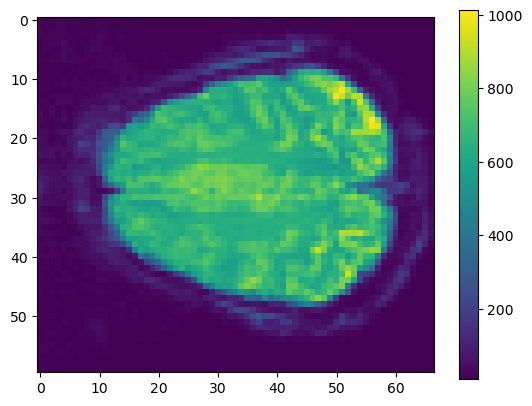

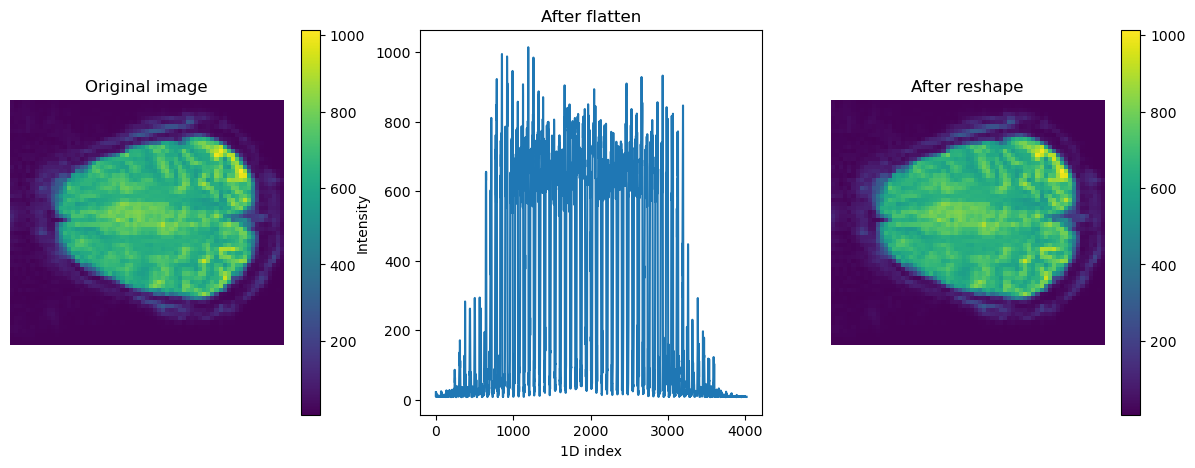

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================================
# background functions: provided to read data

def read_in_dataset(fname):
    """
Parameters
----------
fname_dat : str
    filename of data (of the particular dimensions included in this function)

Returns
-------
data : np.ndarray
    3D array of data, representing a slice of data (first 2 coords) and a time
    series at each location (3rd dimension)
"""

    # read in: brain time series data
    fff = open(fname, "r")
    X = fff.readlines()
    fff.close()
    brain = [line.split() for line in X]

    # dimensions of brain data (slice + time)
    N = 144
    dimx = 70-11+1
    dimy = 74-8+1

    # brain data: initialize+populate
    data = np.zeros((dimx,dimy,N))
    n = 0
    for j in range(0,dimy):
        for i in range(0,dimx):
            for k in range(0,N):
                # don't need these coord values, but just keep track
                x = brain[n][0]
                y = brain[n][1]
                z = brain[n][2]
                data[i,j,k] = brain[n][3+k]
            n+=1

    Nx, Ny, Nt = np.shape(data)

    print("++ Read in data array with dimensions: {}, {}, {}\n"
          "   The first two are spatial dimensions, and the third is time."
          "".format(Nx, Ny, Nt))

    return data

def read_in_refwav(fname):
    """Read in a file fname that contains a single reference time series.

Parameters
----------
fname_ref : str
    filename of reference wave (of particular len included in this function)

Returns
-------
refwav : np.ndarray
    1D array of data, representing reference time series
"""

    # read in: brain time series data
    fff = open(fname, "r")
    X = fff.readlines()
    fff.close()
    boxcar = [line.split() for line in X]

    # dimensions of reference wave (number of time points)
    N = len(boxcar)

    # make refwav
    refwav = np.zeros(N)
    for k in range(0,N):
        refwav[k] = boxcar[k][0]

    print("++ Read in reference time series of length: {}"
          "".format(N))

    return refwav

# =========================================================================

if __name__ == "__main__":
    
    # read in a slice of FMRI data (3D array): first 2 dims are
    # spatial indices, and third is index of time points
    data = read_in_dataset("AIMSftap.dat")
    Nx, Ny, Nt = np.shape(data)

    # the sampling time for this data
    Ts = 2.5

    # read in a reference time series (1D array)
    refwav = read_in_refwav("Ref.1D")
    L = len(refwav)    

    data_mean = np.zeros((Nx, Ny))
    for i in range(Nx):
        for j in range(Ny):
            data_mean[i,j] = np.mean(data[i,j,:])

    #flaten 
    data_flat = data_mean.flatten()
    print(f"Shape 1D : {data_flat.shape}")

    #reshape
    data_reconstructed = data_flat.reshape(Nx,Ny)
    print(f"Shape after reconstruction {data_reconstructed.shape}")

    are_equal = np.allclose(data_mean, data_reconstructed)
    print(f"reconstruction matches orginal:  {are_equal}")
    plt.imshow(data_mean)
    plt.colorbar()



    #visual 
    fig, axes = plt.subplots(1,3, figsize = (15,5))
    im0 = axes[0].imshow(data_mean)
    axes[0].set_title('Original image')
    axes[0].axis('off')
    plt.colorbar(im0, ax = axes[0])


    axes[1].plot(data_flat)
    axes[1].set_title("After flatten")
    axes[1].set_xlabel('1D index')
    axes[1].set_ylabel('Intensity')

    im2 = axes[2].imshow(data_reconstructed)
    axes[2].set_title("After reshape")
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])

    plt.savefig("visual1.png")

    plt.show()

Total voxels     : 4020
Brain voxels     : 1424
Variance explained : [0.26764256 0.06027566 0.04940725 0.03149947 0.02980031]


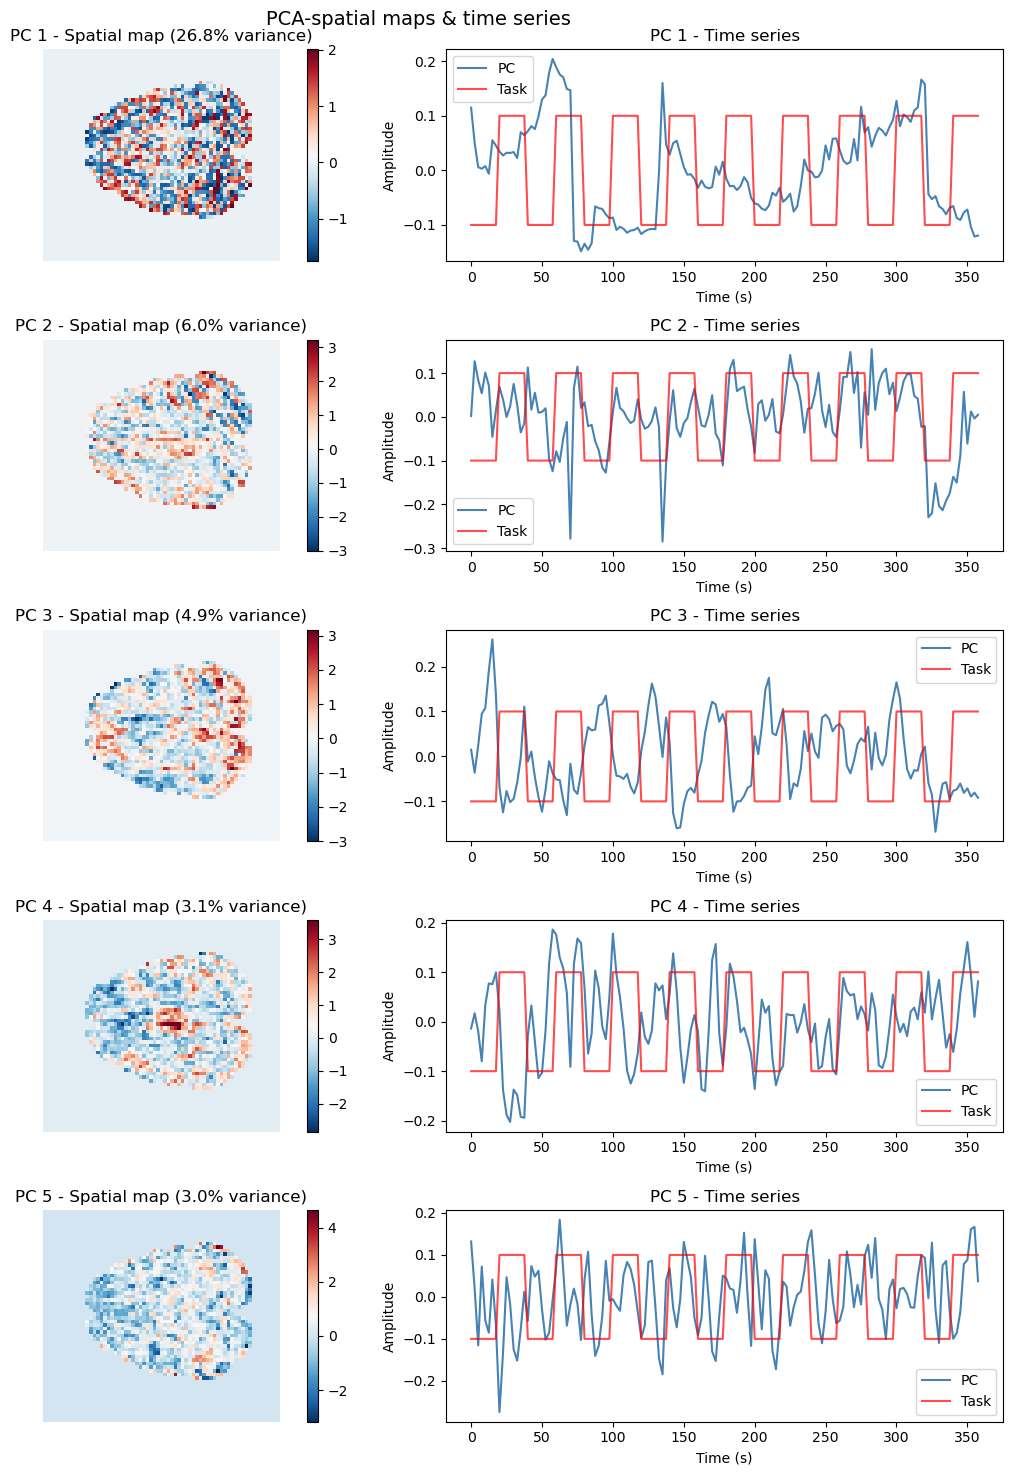

In [16]:
from sklearn.decomposition import PCA
from scipy.stats import zscore

data_flat = data.reshape(Nx*Ny, Nt)

data_mean_flat = data_flat.mean(axis=1)
mask = data_mean_flat >500
data_masked = data_flat[mask, :]

print("Total voxels     : {}".format(Nx * Ny))
print("Brain voxels     : {}".format(data_masked.shape[0]))

data_masked_z = zscore(data_masked, axis = 1)

n_components = 5
pca = PCA(n_components = n_components, whiten = True)
scores = pca.fit_transform(data_masked_z)

print(f"Variance explained : {pca.explained_variance_ratio_}")

time = np.arange(Nt)*Ts


fig, axes = plt.subplots(n_components, 2, figsize = (12,3*n_components))

for i in range(n_components):
    spatial_map_flat = np.zeros(Nx*Ny)
    spatial_map_flat[mask]= scores[:,i]
    spatial_map = spatial_map_flat.reshape(Nx,Ny)
    
    im = axes[i,0].imshow(spatial_map, cmap='RdBu_r')
    axes[i,0].set_title("PC {} - Spatial map ({:.1f}% variance)".format(i+1, pca.explained_variance_ratio_[i]*100))
    axes[i,0].axis('off')
    plt.colorbar(im, ax= axes[i,0])

    refwav_norm = (refwav - refwav.mean())/refwav.std()*0.1
    
    axes[i,1].plot(time, pca.components_[i], color = 'steelblue', label = "PC")
    axes[i,1].plot(time, refwav_norm, color = 'red', alpha = 0.7, label = 'Task')
    axes[i,1].legend()
    axes[i, 1].set_title("PC {} - Time series".format(i+1))
    axes[i,1].set_xlabel("Time (s)")
    axes[i,1].set_ylabel("Amplitude")

plt.suptitle("PCA-spatial maps & time series", fontsize = 14)
plt.tight_layout()
plt.savefig("visual2.png")
plt.show()

- PC 1 (26.8%) : The PC time series has slow drift and does not follow the task pattern at all. This is likely motion/baseline artifact.
- PC 2 (6.0%) : Partially follows the task but has a big artifact around t=75s. Mixed signal.
- PC 3 (4.9%): The blue curve loosely follows the red task wave but with noise. Partial task correlation.
- PC 4 (3.1%) : This is the most interesting one. The PC time series follows the task reference wave quite well — you can see the oscillations align with the ON/OFF blocks. The spatial map also shows a clear structure. This is likely the task-related neural signal.
- PC 5 (3.0%) : Also somewhat correlated with the task but noisier.

In [17]:
from scipy.stats import pearsonr

for i in range(n_components):
    r, p = pearsonr(pca.components_[i], refwav)
    print("PC {} – correlation with task: r={:.3f}, p={:.4f}".format(i+1, r, p))

PC 1 – correlation with task: r=0.001, p=0.9928
PC 2 – correlation with task: r=0.235, p=0.0047
PC 3 – correlation with task: r=-0.486, p=0.0000
PC 4 – correlation with task: r=0.071, p=0.3968
PC 5 – correlation with task: r=0.103, p=0.2182


- PC 3 is clearly the winner with r = -0.486 and p ≈ 0.000.
- The negative sign just means the component is flipped relative to the task wave — that's arbitrary in PCA and doesn't change the interpretation. |r| = 0.486 is the strongest correlation by far.
- Looking back at the plot, this makes sense — PC 3's time series oscillates in opposition to the red task wave (when task is ON, PC 3 goes down, and vice versa).
- PC 2 (r=0.235, p=0.005) has a weaker but still significant correlation — it may capture a delayed hemodynamic response or a secondary task-related network.
- PC 1, 4, 5 are not significantly correlated with the task (p > 0.05) — confirming they represent noise/artifacts

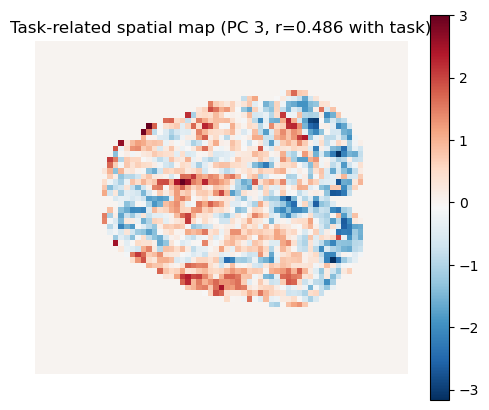

In [18]:
# Flip the sign so it visually matches the task wave
task_component = -pca.components_[2]        # flip sign
task_spatial    = -scores[:, 2]             # flip sign on spatial map too

# Rebuild full spatial map
spatial_map_flat = np.zeros(Nx * Ny)
spatial_map_flat[mask] = task_spatial
task_map = spatial_map_flat.reshape(Nx, Ny)

plt.figure(figsize=(6, 5))
plt.imshow(task_map, cmap='RdBu_r')
plt.colorbar()
plt.title("Task-related spatial map (PC 3, r=0.486 with task)")
plt.axis('off')
plt.savefig("task_map.png")
plt.show()

- Red regions (positive) : brain areas that activate with the task. You can see clusters mainly in the central and posterior parts of the brain slice. These voxels' time series go UP when the task is ON.
- Blue regions (negative): areas that deactivate during the task, or activate during the rest period. A few scattered blue spots, notably on the edges/periphery.
- Beige/white regions : voxels outside the brain mask (mean ≤ 500), correctly excluded from the analysis.